In [79]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

df = pd.DataFrame(
    data.data,
    columns = data.feature_names
)

df["target"] = data.target
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [80]:
print(df.shape)

(569, 31)


In [81]:
print(df["target"].value_counts())

target
1    357
0    212
Name: count, dtype: int64


In [82]:
print(df.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [83]:
X = df.drop("target",axis = 1)

In [84]:
y = df["target"]

In [85]:
from sklearn.model_selection import train_test_split

X_test, X_train , y_test , y_train = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [86]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [87]:
y_pred = model.predict(X_test)

In [88]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test,y_pred))

print("Precision:", precision_score(y_test,y_pred))

print("Recall   :", recall_score(y_test,y_pred))

print("F1 Score :", f1_score(y_test,y_pred))

print(confusion_matrix(y_test,y_pred))

Accuracy : 0.8835164835164835
Precision: 0.911660777385159
Recall   : 0.9020979020979021
F1 Score : 0.9068541300527241
[[144  25]
 [ 28 258]]


In [89]:
print(model.get_depth())

4


In [90]:
print(model.get_n_leaves())

6


In [91]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                Feature  Importance
22      worst perimeter    0.891907
5      mean compactness    0.036807
18       symmetry error    0.034814
11        texture error    0.018670
13           area error    0.017802
2        mean perimeter    0.000000
4       mean smoothness    0.000000
3             mean area    0.000000
6        mean concavity    0.000000
7   mean concave points    0.000000


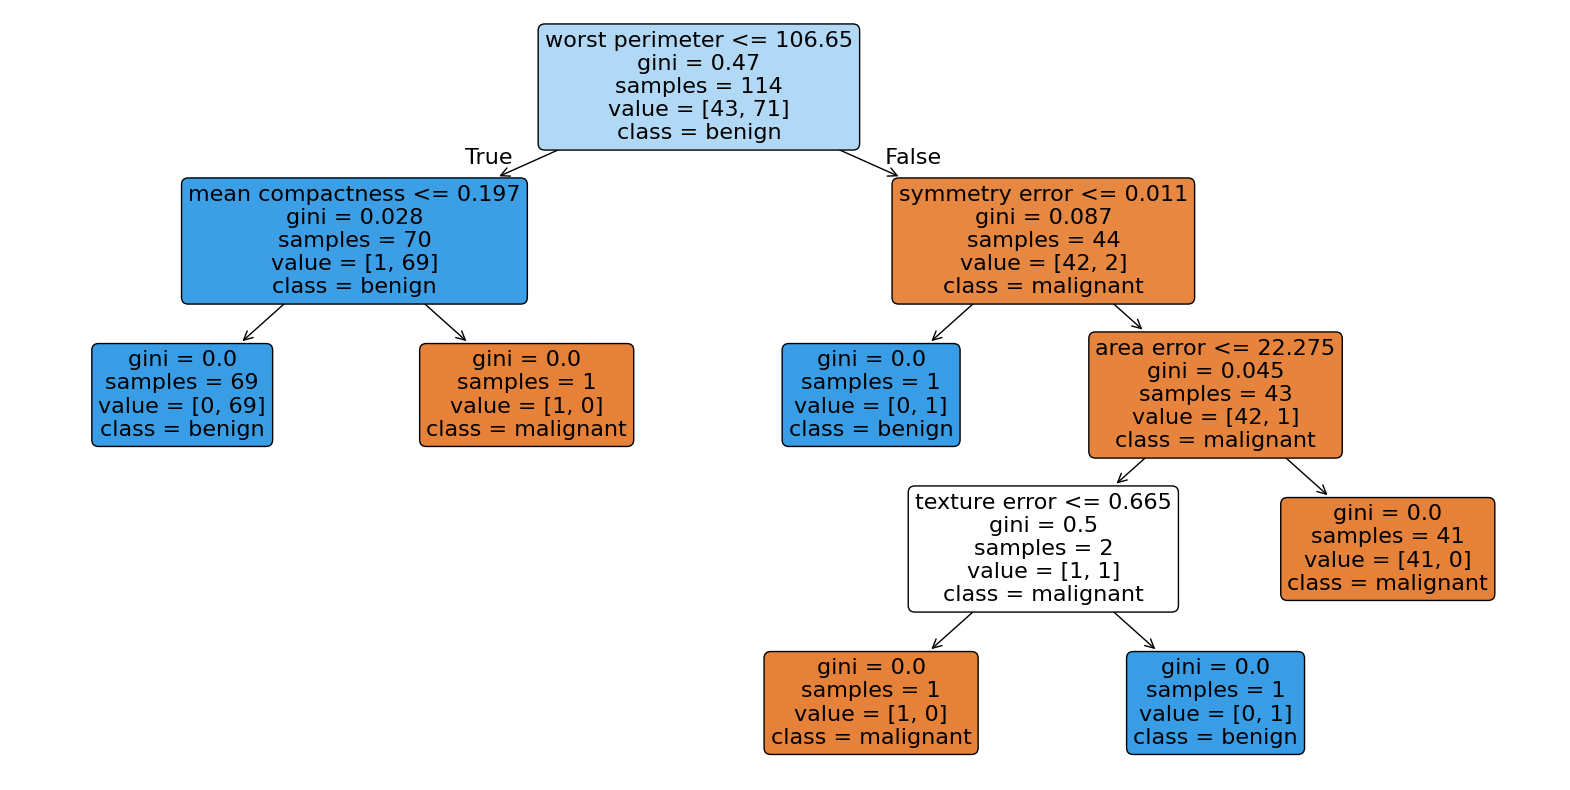

In [92]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=data.target_names,
    filled=True,
    rounded=True
)

plt.show()

In [93]:
model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model.fit(X_train,y_train)

y_pred=model.predict(X_test)

In [94]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test,y_pred))

print("Precision:", precision_score(y_test,y_pred))

print("Recall   :", recall_score(y_test,y_pred))

print("F1 Score :", f1_score(y_test,y_pred))

print(confusion_matrix(y_test,y_pred))

Accuracy : 0.8923076923076924
Precision: 0.9247311827956989
Recall   : 0.9020979020979021
F1 Score : 0.9132743362831859
[[148  21]
 [ 28 258]]


In [95]:
model_gini = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

model_gini.fit(X_train, y_train)

y_pred_gini = model_gini.predict(X_test)

In [96]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test,y_pred_gini))

print("Precision:", precision_score(y_test,y_pred_gini))

print("Recall   :", recall_score(y_test,y_pred_gini))

print("F1 Score :", f1_score(y_test,y_pred_gini))

print(confusion_matrix(y_test,y_pred_gini))

Accuracy : 0.8835164835164835
Precision: 0.911660777385159
Recall   : 0.9020979020979021
F1 Score : 0.9068541300527241
[[144  25]
 [ 28 258]]


In [97]:
model_entropy = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

model_entropy.fit(X_train, y_train)

y_pred_entropy = model_entropy.predict(X_test)

In [98]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test,y_pred_entorpy))

print("Precision:", precision_score(y_test,y_pred_entorpy))

print("Recall   :", recall_score(y_test,y_pred_entorpy))

print("F1 Score :", f1_score(y_test,y_pred_entorpy))

print(confusion_matrix(y_test,y_pred_entorpy))

Accuracy : 0.8923076923076924
Precision: 0.9247311827956989
Recall   : 0.9020979020979021
F1 Score : 0.9132743362831859
[[148  21]
 [ 28 258]]


In [99]:
print(model_gini.get_depth())
print(model_entropy.get_depth())

print(model_gini.get_n_leaves())
print(model_entropy.get_n_leaves())

4
3
6
5


In [104]:
model_improve = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

model_improve.fit(X_train,y_train)

y_pred_improve = model_improve.predict(X_test)

In [105]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test,y_pred_improve))

print("Precision:", precision_score(y_test,y_pred_improve))

print("Recall   :", recall_score(y_test,y_pred_improve))

print("F1 Score :", f1_score(y_test,y_pred_improve))

print(confusion_matrix(y_test,y_pred_improve))

Accuracy : 0.8989010989010989
Precision: 0.9285714285714286
Recall   : 0.9090909090909091
F1 Score : 0.9187279151943463
[[149  20]
 [ 26 260]]
